# 🏆 The Golden Rules of Neural Network Training
## Dataset: CIFAR-10 | Framework: PyTorch

Following the 4-step progression from the *Regularisation Techniques* diagram:

| Step | Name | Config | Goal |
|------|------|--------|------|
| 1 | **Sanity Check** | 1 sample + simple model | Verify code is correct |
| 2 | **Baseline** | Full data + simple model | Establish a number to beat |
| 3 | **Reduce Bias** | Full data + complex model | Fix underfitting |
| 4 | **Reduce Variance** | Full data + complex model + regularisation | Reach Gold Standard |

---

## 0. Environment Setup & Reproducibility

> Fix every random seed before importing data or building models   
> This guarantees that re-running this notebook top-to-bottom always produces identical numbers.  

In [1]:
import os, random, time
import numpy as np
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset
import matplotlib.pyplot as plt
import seaborn as sns

# ── Reproducibility ───────────────────────────────────────────────
SEED = 42

def set_seed(seed=SEED):
    """Pin ALL random sources — Python, NumPy, PyTorch CPU+GPU."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ['PYTHONHASHSEED'] = str(seed)
    print(f'Seed fixed to {seed} ✔')

set_seed()

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')
print(f'PyTorch version: {torch.__version__}')

Seed fixed to 42 ✔
Device: cuda
PyTorch version: 2.10.0+cu128


## 1. Dataset — CIFAR-10

> Dataset: CIFAR-10
   - 60 000 images and 10 classes.
   - Directly downloadable via torchvision

100%|██████████| 170M/170M [00:03<00:00, 43.6MB/s]


Train: 50,000 | Val: 10,000 | Augment: False
Batch shape: torch.Size([128, 3, 32, 32])  |  Labels shape: torch.Size([128])


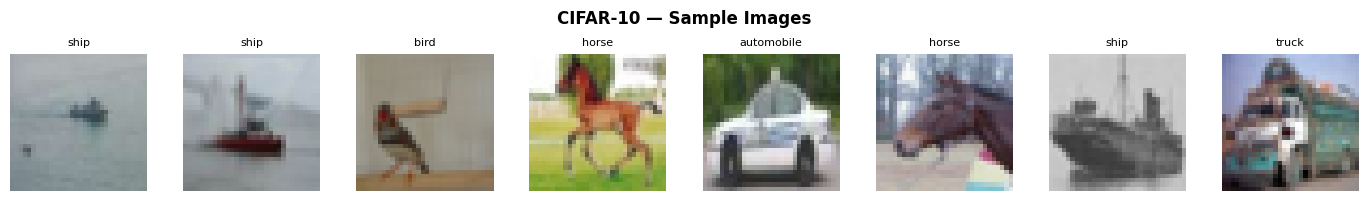

In [2]:
# ── Constants ─────────────────────────────────────────────────────
BATCH_SIZE   = 128
NUM_CLASSES  = 10
CLASSES      = ['airplane','automobile','bird','cat','deer',
                'dog','frog','horse','ship','truck']

# Normalisation statistics for CIFAR-10 (pre-computed over train set)
# using the actual dataset mean/std instead of 0.5/0.5
MEAN = (0.4914, 0.4822, 0.4465)
STD  = (0.2470, 0.2435, 0.2616)

# Basic transform just resize and convert to tensor and normalise it
basic_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

# We make here Augmented transform
# trying to make some random flips and crops
# this like we collect more data without collecting new samples
# we use it in traning only
aug_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomCrop(32, padding=4),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

def get_loaders(augment=False, root='./data'):
    train_tf = aug_transform if augment else basic_transform
    g = torch.Generator(); g.manual_seed(SEED)
    train_ds = torchvision.datasets.CIFAR10(root, train=True,  download=True, transform=train_tf)
    val_ds   = torchvision.datasets.CIFAR10(root, train=False, download=True, transform=basic_transform)
    train_ld = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, generator=g)
    val_ld   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
    print(f'Train: {len(train_ds):,} | Val: {len(val_ds):,} | Augment: {augment}')
    return train_ld, val_ld

# Peek at one batch to confirm shapes are correct
train_loader, val_loader = get_loaders(augment=False)
imgs, labels = next(iter(train_loader))
print(f'Batch shape: {imgs.shape}  |  Labels shape: {labels.shape}')

# Visualise 8 sample images
fig, axes = plt.subplots(1, 8, figsize=(14, 2))
unnorm = lambda x: (x * torch.tensor(STD).view(3,1,1)) + torch.tensor(MEAN).view(3,1,1)
for i, ax in enumerate(axes):
    img = unnorm(imgs[i]).permute(1,2,0).clamp(0,1).numpy()
    ax.imshow(img); ax.set_title(CLASSES[labels[i].item()], fontsize=8); ax.axis('off')
plt.suptitle('CIFAR-10 — Sample Images', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

## 2. Model Architectures

> - `SimpleCNN` that's met Step 2 "Establish Baseline" .  
> - `DeepCNN` that's met Step 3 "Reduce Bias" + Step 4 "Reduce Variance".  

In [3]:
class SimpleCNN(nn.Module):
    """the baseline model: 2 conv blocks + 1 fully connected head."""
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            # extract low level features like edges and colours
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(True), nn.MaxPool2d(2),
            # combine these low level features into shapes
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(True), nn.MaxPool2d(2),
            # classifier head
            nn.Flatten(),
            nn.Linear(64*8*8, 256), nn.ReLU(True),
            nn.Linear(256, NUM_CLASSES),
        )

    def forward(self, x):
      """here we go to the forward path"""
      return self.net(x)


class DeepCNN(nn.Module):
    """
    This is Improved model used in step 3 & 4
    - Step 3 (Fix Underfitting)  : use_dropout=False
    - Step 4 (Fix Overfitting)   : use_dropout=True
    """
    def __init__(self, use_dropout=False):
        super().__init__()
        p = 0.5 if use_dropout else 0.0
        self.features = nn.Sequential(
            nn.Conv2d(3, 64, 3, padding=1),  nn.BatchNorm2d(64),  nn.ReLU(True),
            nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64),  nn.ReLU(True), nn.MaxPool2d(2),  # 16x16
            nn.Conv2d(64,128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(True),
            nn.Conv2d(128,128,3, padding=1), nn.BatchNorm2d(128), nn.ReLU(True), nn.MaxPool2d(2),  # 8x8
            nn.Conv2d(128,256,3, padding=1), nn.BatchNorm2d(256), nn.ReLU(True), nn.MaxPool2d(2),  # 4x4
            nn.Conv2d(256,256,3, padding=1), nn.BatchNorm2d(256), nn.ReLU(True),
            nn.AdaptiveAvgPool2d(1),  # Global average pooling → 1x1
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 512), nn.ReLU(True),
            nn.Dropout(p),
            nn.Linear(512, NUM_CLASSES),
        )
    def forward(self, x): return self.classifier(self.features(x))


def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f'SimpleCNN params : {count_params(SimpleCNN()):>10,}')
print(f'DeepCNN params   : {count_params(DeepCNN()):>10,}')

SimpleCNN params :  1,070,986
DeepCNN params   :  1,283,914



*(DeepCNN has ~4× more parameters — that extra capacity is what fixes underfitting in Step 3)*

## 3. Training Engine

In [4]:
def train_one_epoch(model, loader, optimizer, criterion, device=DEVICE):
    """One full pass over the training set."""
     # activates Dropout, BatchNorm in train mode
    model.train()
    total_loss, correct, total = 0., 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        logits = model(imgs)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        correct += (logits.argmax(1) == labels).sum().item()
        total += imgs.size(0)
    return total_loss / total, 100. * correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device=DEVICE):
    """
    One full pass over a validation / test set
    we don't need to calculate the gradient here
    """
    # deactivates Dropout,
    model.eval()
    total_loss, correct, total = 0., 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        logits = model(imgs)
        loss = criterion(logits, labels)
        total_loss += loss.item() * imgs.size(0)
        correct += (logits.argmax(1) == labels).sum().item()
        total += imgs.size(0)
    return total_loss / total, 100. * correct / total


def fit(model, train_ld, val_ld, optimizer, criterion, epochs, label=''):
    """Run full training loop and return history dict."""
    model = model.to(DEVICE)
    history = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[]}
    best_val = 0.
    print(f'\n--- {label} ---')
    for ep in range(1, epochs+1):
        tr_l, tr_a = train_one_epoch(model, train_ld, optimizer, criterion)
        vl_l, vl_a = evaluate(model, val_ld, criterion)
        history['train_loss'].append(tr_l); history['val_loss'].append(vl_l)
        history['train_acc'].append(tr_a);  history['val_acc'].append(vl_a)
        if vl_a > best_val: best_val = vl_a
        print(f'  Ep {ep:>2}/{epochs}  TrainLoss={tr_l:.4f}  TrainAcc={tr_a:.1f}%  '
              f'ValLoss={vl_l:.4f}  ValAcc={vl_a:.1f}%')
    print(f'  → Best Val Acc: {best_val:.1f}%')
    return history, best_val


def plot_history(history, title, has_val=True):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(history['train_loss'], label='Train', color='royalblue')
    if has_val and 'val_loss' in history:
        ax1.plot(history['val_loss'], label='Val', color='tomato', ls='--')
    ax1.set_title(f'{title} — Loss'); ax1.set_xlabel('Epoch'); ax1.legend(); ax1.grid(alpha=.3)
    ax2.plot(history['train_acc'], label='Train', color='seagreen')
    if has_val and 'val_acc' in history:
        ax2.plot(history['val_acc'], label='Val', color='darkorange', ls='--')
    ax2.set_title(f'{title} — Accuracy'); ax2.set_xlabel('Epoch'); ax2.set_ylabel('%')
    ax2.legend(); ax2.grid(alpha=.3)
    plt.tight_layout(); plt.show()

criterion = nn.CrossEntropyLoss()
print('Training engine ready ✔')

Training engine ready ✔


---
## STEP 1 — SANITY CHECK
### "Few data, Simple model" — Code Verification


> Before training on the full dataset we must ensure

> the forward pass works without any problem and the loss decrease

> if the model fail here -> there is a bug we must handle it

Single sample class: "frog" ← will try to memorise this
Seed fixed to 42 ✔
  Epoch   1  Loss: 2.102274  Acc: 0.0%
  Epoch  25  Loss: 0.000000  Acc: 100.0%
  Epoch  50  Loss: 0.000000  Acc: 100.0%
  Epoch  75  Loss: 0.000000  Acc: 100.0%
  Epoch 100  Loss: 0.000000  Acc: 100.0%
  Epoch 125  Loss: 0.000000  Acc: 100.0%
  Epoch 150  Loss: 0.000000  Acc: 100.0%
  Epoch 175  Loss: 0.000000  Acc: 100.0%
  Epoch 200  Loss: 0.000000  Acc: 100.0%

Sanity Check ✅ PASSED  (final loss = 0.000000)


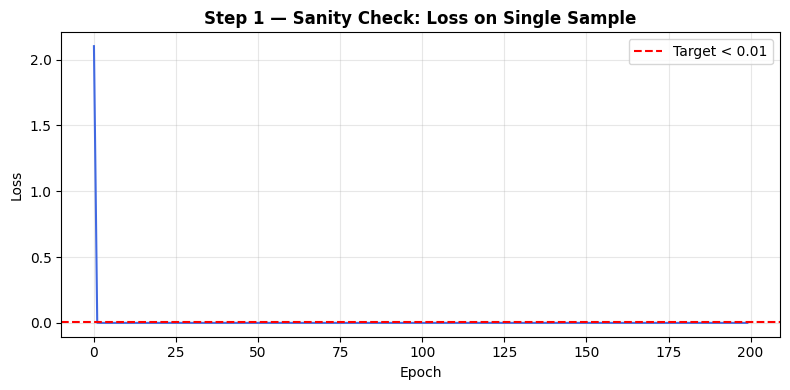

In [5]:
# ── Build the 1-sample loader ──
full_train = torchvision.datasets.CIFAR10('./data', train=True, download=True, transform=basic_transform)
single_ds  = Subset(full_train, [0])
single_ld  = DataLoader(single_ds, batch_size=1, shuffle=False)

label_name = CLASSES[full_train.targets[0]]
print(f'Single sample class: "{label_name}" ← will try to memorise this')

# ── Train ──────────────────────────────────────────────────────────
set_seed(SEED)
model_s1   = SimpleCNN().to(DEVICE)
opt_s1     = torch.optim.Adam(model_s1.parameters(), lr=1e-3)
losses_s1  = []

for ep in range(1, 201):
    l, a = train_one_epoch(model_s1, single_ld, opt_s1, criterion)
    losses_s1.append(l)
    if ep % 25 == 0 or ep == 1:
        print(f'  Epoch {ep:>3}  Loss: {l:.6f}  Acc: {a:.1f}%')

# ── Verdict ────────────────────────────────────────────────────────
final = losses_s1[-1]
status = '✅ PASSED' if final < 0.01 else '❌ FAILED'
print(f'\nSanity Check {status}  (final loss = {final:.6f})')

# ── Plot ───────────────────────────────────────────────────────────
plt.figure(figsize=(8,4))
plt.plot(losses_s1, color='royalblue')
plt.axhline(0.01, color='red', ls='--', label='Target < 0.01')
plt.title('Step 1 — Sanity Check: Loss on Single Sample', fontweight='bold')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend(); plt.grid(alpha=.3)
plt.tight_layout(); plt.show()

---
## STEP 2 — ESTABLISH BASELINE
### "Training data, Simple model" — Measure Underfitting
> Now we train on the full dataset with the same simple model.

> Expected outcome: train loss ↓ but val accuracy will plateau

> We don't try to fix it here; we just measure the problem.

Seed fixed to 42 ✔
Train: 50,000 | Val: 10,000 | Augment: False
SimpleCNN params: 1,070,986

--- Step 2 — Baseline ---
  Ep  1/10  TrainLoss=1.3027  TrainAcc=53.6%  ValLoss=1.0847  ValAcc=60.4%
  Ep  2/10  TrainLoss=0.9217  TrainAcc=67.6%  ValLoss=0.9455  ValAcc=67.1%
  Ep  3/10  TrainLoss=0.8018  TrainAcc=71.8%  ValLoss=0.8707  ValAcc=69.8%
  Ep  4/10  TrainLoss=0.7143  TrainAcc=74.8%  ValLoss=0.8097  ValAcc=71.9%
  Ep  5/10  TrainLoss=0.6416  TrainAcc=77.7%  ValLoss=0.7988  ValAcc=72.9%
  Ep  6/10  TrainLoss=0.5776  TrainAcc=79.5%  ValLoss=0.7632  ValAcc=74.3%
  Ep  7/10  TrainLoss=0.5180  TrainAcc=81.8%  ValLoss=0.8154  ValAcc=72.6%
  Ep  8/10  TrainLoss=0.4626  TrainAcc=83.7%  ValLoss=0.8159  ValAcc=73.8%
  Ep  9/10  TrainLoss=0.4136  TrainAcc=85.4%  ValLoss=0.8334  ValAcc=74.3%
  Ep 10/10  TrainLoss=0.3629  TrainAcc=87.3%  ValLoss=0.8842  ValAcc=73.8%
  → Best Val Acc: 74.3%


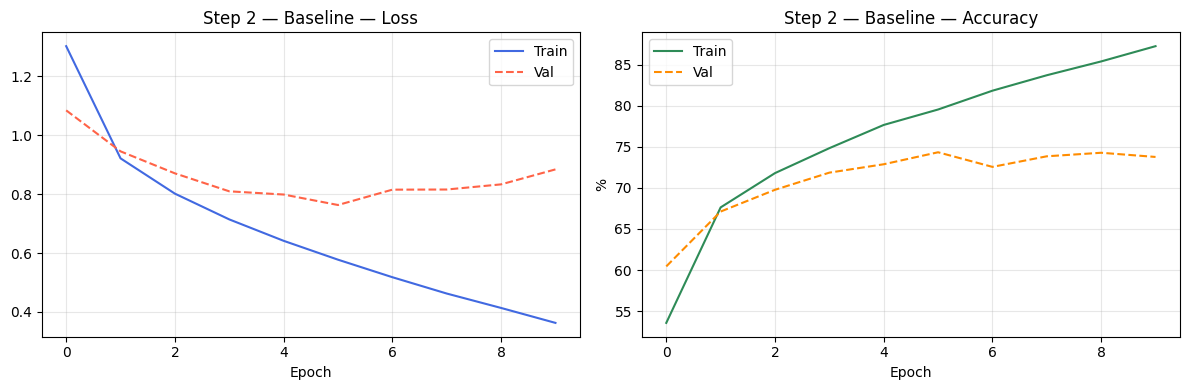


Train–Val accuracy gap: 12.9%
→ Large gap: overfitting (model memorises train, fails on val)


In [6]:
set_seed(SEED)
train_loader, val_loader = get_loaders(augment=False)

model_s2   = SimpleCNN()
opt_s2     = torch.optim.Adam(model_s2.parameters(), lr=1e-3)

print(f'SimpleCNN params: {count_params(model_s2):,}')
hist_s2, best_s2 = fit(model_s2, train_loader, val_loader, opt_s2, criterion,
                       epochs=10, label='Step 2 — Baseline')

plot_history(hist_s2, 'Step 2 — Baseline')

gap = max(hist_s2['train_acc']) - max(hist_s2['val_acc'])
print(f'\nTrain–Val accuracy gap: {gap:.1f}%')
if gap < 5:
    print('→ Small gap: underfitting (model too simple, not learning enough)')
else:
    print('→ Large gap: overfitting (model memorises train, fails on val)')

---
## STEP 3 — REDUCE BIAS (Fix Underfitting)
### "Training data, Complex model" — Add Capacity

- We swap SimpleCNN for DeepCNN.
- More layers = more capacity = the model can fit the data.
- Expected outcome: both train AND val accuracy increase.
- BUT — train acc will climb much faster than val acc,
 the model starts to overfit (high variance).

Seed fixed to 42 ✔
Train: 50,000 | Val: 10,000 | Augment: False
DeepCNN params: 1,283,914  (vs SimpleCNN: 1,070,986)

--- Step 3 — Reduce Bias ---
  Ep  1/20  TrainLoss=1.1893  TrainAcc=56.3%  ValLoss=1.1833  ValAcc=57.9%
  Ep  2/20  TrainLoss=0.7470  TrainAcc=73.5%  ValLoss=0.7932  ValAcc=72.1%
  Ep  3/20  TrainLoss=0.5707  TrainAcc=79.9%  ValLoss=0.8703  ValAcc=71.2%
  Ep  4/20  TrainLoss=0.4625  TrainAcc=83.9%  ValLoss=0.5946  ValAcc=80.0%
  Ep  5/20  TrainLoss=0.3761  TrainAcc=87.0%  ValLoss=0.5957  ValAcc=80.6%
  Ep  6/20  TrainLoss=0.3041  TrainAcc=89.4%  ValLoss=0.8678  ValAcc=73.9%
  Ep  7/20  TrainLoss=0.2406  TrainAcc=91.6%  ValLoss=0.6294  ValAcc=81.0%
  Ep  8/20  TrainLoss=0.1965  TrainAcc=93.1%  ValLoss=0.5956  ValAcc=83.1%
  Ep  9/20  TrainLoss=0.1523  TrainAcc=94.7%  ValLoss=0.7326  ValAcc=80.6%
  Ep 10/20  TrainLoss=0.1216  TrainAcc=95.7%  ValLoss=1.1871  ValAcc=73.3%
  Ep 11/20  TrainLoss=0.1030  TrainAcc=96.3%  ValLoss=0.7528  ValAcc=81.3%
  Ep 12/20  TrainLoss=0.0855

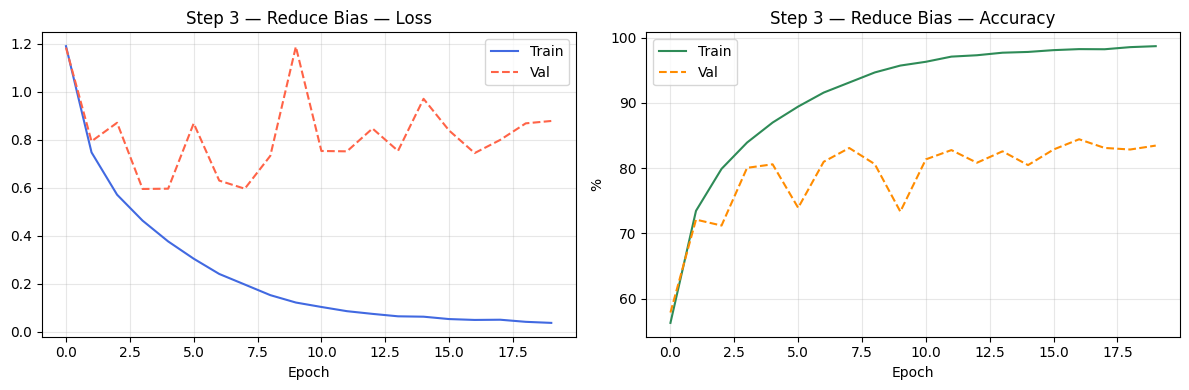


Train–Val gap (final epoch): 15.2%
→ If gap > 15% → model is overfitting → need Step 4 regularisation


In [7]:
set_seed(SEED)
# Same loaders, no augmentation yet (only one change at a time!)
train_loader, val_loader = get_loaders(augment=False)

model_s3   = DeepCNN(use_dropout=False)  # deep but no regularisation
opt_s3     = torch.optim.Adam(model_s3.parameters(), lr=1e-3)

print(f'DeepCNN params: {count_params(model_s3):,}  (vs SimpleCNN: {count_params(SimpleCNN()):,})')
hist_s3, best_s3 = fit(model_s3, train_loader, val_loader, opt_s3, criterion,
                       epochs=20, label='Step 3 — Reduce Bias')

plot_history(hist_s3, 'Step 3 — Reduce Bias')

gap_s3 = max(hist_s3['train_acc']) - hist_s3['val_acc'][-1]
print(f'\nTrain–Val gap (final epoch): {gap_s3:.1f}%')
print('→ If gap > 15% → model is overfitting → need Step 4 regularisation')

---
## STEP 4 — REDUCE VARIANCE (Fix Overfitting) 🏆
### "Training data, Complex model, Regularisation" — The Gold Standard

> We keep the same DeepCNN but add three regularisation techniques:
>   1. Dropout (p=0.5)   — randomly zeros half the activations each step
>   2. Weight Decay (L2) — penalises large weights in the optimiser
>   3. Data Augmentation — random flips & crops = "free" extra data
>
> The combination should close the train–val gap and push val acc higher.
> This is the "Gold Standard" end goal.

In [ ]:
set_seed(SEED)
train_loader_aug, val_loader = get_loaders(augment=True)  # augmented training!

model_s4 = DeepCNN(use_dropout=True)   # Dropout ON
opt_s4   = torch.optim.Adam(
    model_s4.parameters(),
    lr=1e-3,
    weight_decay=1e-4    # L2 regularisation
)

hist_s4, best_s4 = fit(model_s4, train_loader_aug, val_loader, opt_s4, criterion,
                       epochs=30, label='Step 4 — Reduce Variance (Regularised)')

plot_history(hist_s4, 'Step 4 — Reduce Variance')

gap_s4 = max(hist_s4['train_acc']) - max(hist_s4['val_acc'])
print(f'\nTrain–Val gap: {gap_s4:.1f}%  (was ~15% in Step 3 → improvement!)')

Seed fixed to 42 ✔
Train: 50,000 | Val: 10,000 | Augment: True

--- Step 4 — Reduce Variance (Regularised) ---
  Ep  1/30  TrainLoss=1.3855  TrainAcc=49.0%  ValLoss=1.3588  ValAcc=54.9%
  Ep  2/30  TrainLoss=0.9377  TrainAcc=66.7%  ValLoss=0.8624  ValAcc=70.2%
  Ep  3/30  TrainLoss=0.7600  TrainAcc=73.4%  ValLoss=0.6799  ValAcc=76.0%
  Ep  4/30  TrainLoss=0.6556  TrainAcc=77.2%  ValLoss=0.7296  ValAcc=76.0%
  Ep  5/30  TrainLoss=0.5850  TrainAcc=80.0%  ValLoss=0.5975  ValAcc=80.2%


---
## 📊 Final Comparison

> The bar chart below is the measure of the entire experiment.  
> Each bar represents one step of the Golden Rules.  
> The progression from left to right should monotonically increase  
> (each step should improve on the previous) — if it doesn't, something went wrong.

In [ ]:
# Summary table
results = {
    'Step 2\nBaseline\n(SimpleCNN)':         best_s2,
    'Step 3\nReduce Bias\n(DeepCNN, no reg)': best_s3,
    'Step 4\nReduce Variance\n(DeepCNN + reg)': best_s4,
}

print('='*55)
print('  FINAL RESULTS SUMMARY')
print('='*55)
for name, acc in results.items():
    bar = '█' * int(acc / 2)
    print(f'  {name[:20]:<22} {acc:5.1f}%  {bar}')
print('='*55)
print(f'  Total improvement: +{best_s4 - best_s2:.1f}%')

# Bar chart
labels   = list(results.keys())
val_accs = list(results.values())
colors   = sns.color_palette('viridis', 3)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(labels, val_accs, color=colors, edgecolor='black', width=0.5)
for bar, acc in zip(bars, val_accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{acc:.1f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')
ax.set_ylim(0, 100)
ax.set_ylabel('Validation Accuracy (%)', fontsize=12)
ax.set_title('CIFAR-10 — Golden Rules Comparison 🏆', fontsize=14, fontweight='bold')
ax.axhline(90, color='gold', ls='--', lw=2, label='Gold Standard target')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

---
## Conclusion

| Observation | What it means | Fix |
|-------------|---------------|-----|
| Step 1 loss → 0 | Code is correct  | — |
| Step 2: small train–val gap, low accuracy | **Underfitting** (high bias) | Bigger model |
| Step 3: large train–val gap | **Overfitting** (high variance) | Regularisation |
| Step 4: gap narrows, val acc improves | Regularisation working  | Keep tuning |
